In [4]:
!pip install wfdb

   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
   -- ------------------------------------- 0.8/11.0 MB 3.7 MB/s eta 0:00:03
   ---- ----------------------------------- 1.3/11.0 MB 3.9 MB/s eta 0:00:03
   -------- ------------------------------- 2.4/11.0 MB 3.8 MB/s eta 0:00:03
   ------------ --------------------------- 3.4/11.0 MB 3.9 MB/s eta 0:00:02
   --------------- ------------------------ 4.2/11.0 MB 3.9 MB/s eta 0:00:02
   ------------------ --------------------- 5.0/11.0 MB 3.9 MB/s eta 0:00:02
   -------------------- ------------------- 5.8/11.0 MB 3.9 MB/s eta 0:00:02
   ----------------------- ---------------- 6.6/11.0 MB 3.9 MB/s eta 0:00:02
   -------------------------- ------------- 7.3/11.0 MB 3.9 MB/s eta 0:00:01
   ----------------------------- ---------- 8.1/11.0 MB 3.9 MB/s eta 0:00:01
   -------------------------------- ------- 8.9/11.0 MB 3.9 MB/s eta 0:00:01
   ------------------------------------ --- 10.0/11.0 MB 3.9 MB/s eta 0:00:01
   --

In [6]:
import wfdb
import matplotlib.pyplot as plt

ECG shape: (650000, 2)


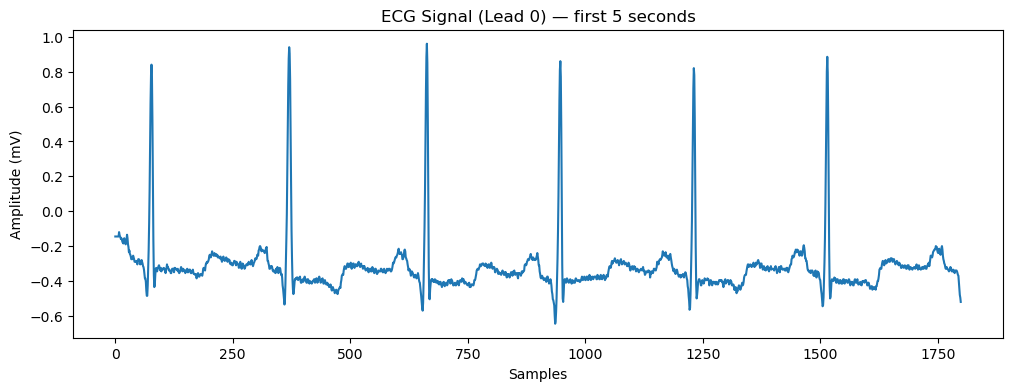

In [10]:

# Loading record 100
record = wfdb.rdrecord('../Data/Raw/100')

# Extract signal
ecg = record.p_signal  
print("ECG shape:", ecg.shape)

# Plot first 5 seconds of lead 0
fs = record.fs  # sampling frequency
plt.figure(figsize=(12,4))
plt.plot(ecg[:5*fs, 0])
plt.title("ECG Signal (Lead 0) — first 5 seconds")
plt.xlabel("Samples")
plt.ylabel("Amplitude (mV)")
plt.show()

In [14]:
with open('../Data/Raw/100.hea', 'r') as f:
    lines = f.readlines()
    
for line in lines:
    print(line.strip())

100 2 360 650000
100.dat 212 200 11 1024 995 -22131 0 MLII
100.dat 212 200 11 1024 1011 20052 0 V5
# 69 M 1085 1629 x1
# Aldomet, Inderal


### Info
69 → Patient age | M → Sex (Male) | 1085 1629 → Possibly weight, height, or IDs | x1 → optional info | Aldomet, Inderal → Medications taken

First 10 beat positions: [  18   77  370  662  946 1231 1515 1809 2044 2402]
First 10 beat symbols: ['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N']


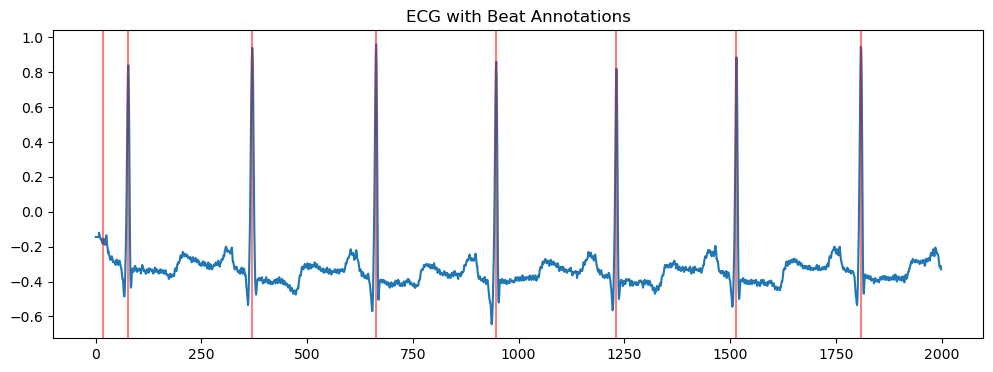

In [18]:
annotation = wfdb.rdann('../Data/Raw/100', 'atr')

# Sample indices of beats
print("First 10 beat positions:", annotation.sample[:10])

# Beat symbols (type)
print("First 10 beat symbols:", annotation.symbol[:10])

# Plot ECG with annotations
plt.figure(figsize=(12,4))
plt.plot(record.p_signal[:2000,0])  # first 2000 samples
for i, s in zip(annotation.sample, annotation.symbol):
    if i < 2000:  # only plot first 2000 samples
        plt.axvline(i, color='r', alpha=0.5)
plt.title("ECG with Beat Annotations")
plt.show()


In [20]:
with open('../Data/Raw/100.xws', 'rb') as f:
    data = f.read()
print(type(data), len(data))


<class 'bytes'> 88


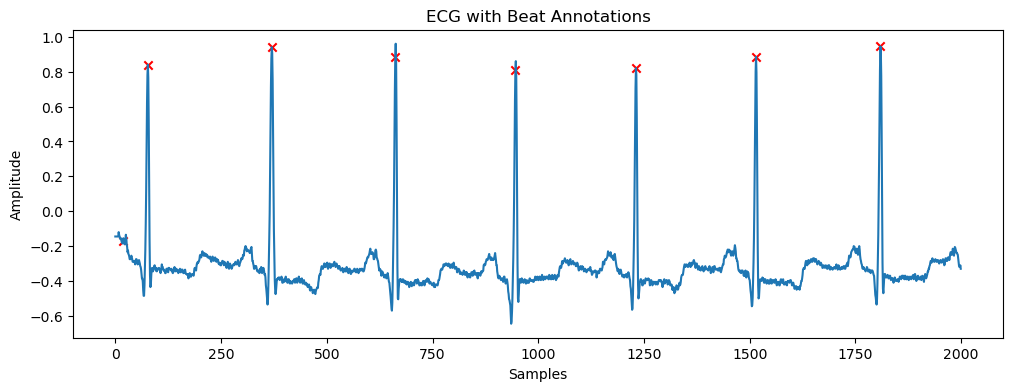

In [22]:
import numpy as np

plt.figure(figsize=(12,4))
plt.plot(record.p_signal[:2000,0], label='ECG')
for idx, sym in zip(annotation.sample, annotation.symbol):
    if idx < 2000:
        plt.scatter(idx, record.p_signal[idx,0], label=sym, marker='x', color='red')
plt.title("ECG with Beat Annotations")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()


Signal shape: (650000, 2)
Leads: ['MLII', 'V5']
Sampling freq: 360


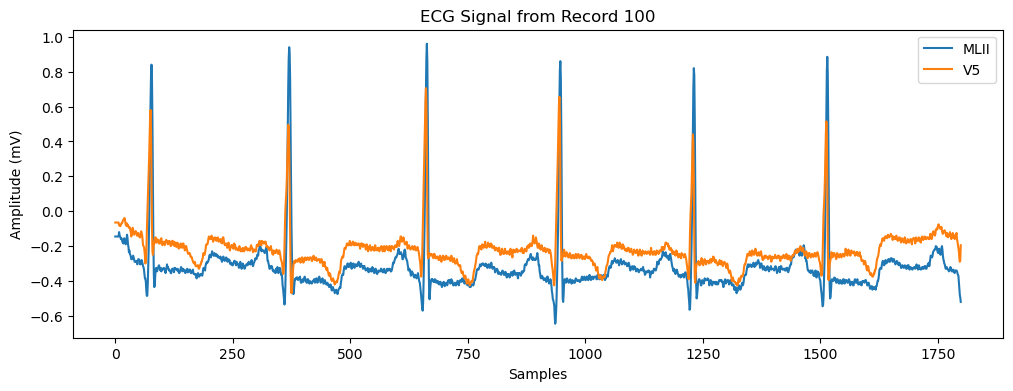

In [24]:
print("Signal shape:", record.p_signal.shape)
print("Leads:", record.sig_name)
print("Sampling freq:", record.fs)

# Plot first 5 seconds
fs = record.fs
plt.figure(figsize=(12,4))
plt.plot(record.p_signal[:5*fs,0], label='MLII')
plt.plot(record.p_signal[:5*fs,1], label='V5')
plt.title('ECG Signal from Record 100')
plt.xlabel('Samples')
plt.ylabel('Amplitude (mV)')
plt.legend()
plt.show()
